# Лабораторная работа 4

# Правильный многоугольник Рело. Векторизация вычислений в numpy


*Радивилова Екатерина*, 08.04.2026

## Задание 4.1. Построение треугольника Рело


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import math

In [21]:
n=3
center=np.array([0, 0])
r=10.
N=100

**Этап 1. Вычисление координат вершин правильного треугольника**


Вершины правильного многоугольника расположены на окружности, описанной
вокруг многоугольника. Радиус $R$ окружности, описанной вокруг правильного
-угольника с длиной стороны , вычисляется по формуле
$$
R=l/(2 sin π/n)
$$

Длина стороны $r$ правильного треугольника, на котором будем строить треугольник
Рело, совпадает с шириной треугольника Рело $r$.


In [22]:
l=r

Вычислим радиус описанной окружности $R$

In [23]:
R=l/(2*np.sin(np.pi/n))

Зафиксируем прямоугольную декартову систему координат. Центр треугольника
размещаем в точке center . Построим матрицу vertices с координатами
вершин правильного треугольника, используя параметрическое описание точек
описанной окружности по формуле $x(t)=x_{0}+Rcos(t), y(t)=y_{0}+Rsin(t)$ для $t \in$ $ {0, 2π/3, 4π/3}.$

In [24]:
t=np.arange(0, 2*np.pi, 2*np.pi/n)
vertices=center+R*np.transpose([np.cos(t), np.sin(t)])
print(vertices)

[[ 5.77350269  0.        ]
 [-2.88675135  5.        ]
 [-2.88675135 -5.        ]]


Массив vertices вычислен без явного использования
циклов. Массив vertices построен за счет итерационного прохода по элементам
массива t . Приведенный код является иллюстрацией векторизации вычислений в
numpy .


Для доступа к элементам матрицы в numpy можно использовать индексацию с
двумя индексами

In [25]:
vertices[0, 0], vertices[0,:], vertices[:, 1]

(np.float64(5.773502691896258),
 array([5.77350269, 0.        ]),
 array([ 0.,  5., -5.]))

Построим изображение вершин треугольника

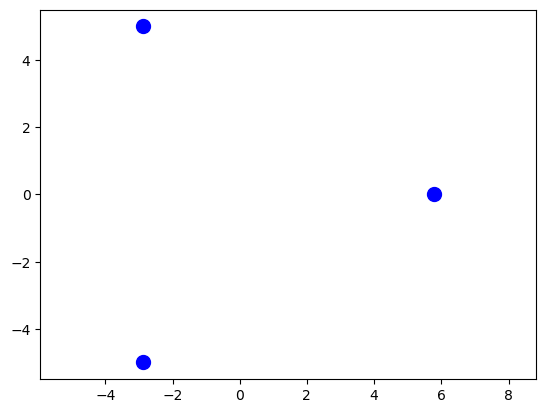

In [26]:
plt.plot(vertices[:,0], vertices[:, 1], 'b.', markersize=20)
plt.axis('equal');

**Этап 2. Представление одной стороны треугольника Рело**


Обозначим через $\alpha$ центральный угол, соответствующий стороне правильног
$n$-угольника. Тогда
$$
\alpha = 2π/n
$$

Обозначим через $\beta$ центральный угол, соответствующий стороне правильного
многоугольника Рело, когда центр окружности расположен в вершине правильного
многоугольника. Тогда
$$
\beta =\alpha/2
$$
Необходимо построить матрицу с координатами точек, описывающих одну сторону
треугольника Рело относительно вершины vertices[0] . Сторона представляет
собой дугу окружности радиуса с центром в точке vertices[0] и значением
угла $[π-\beta/2, π+\beta/2]$

Вычислим значения введенных величин $\alpha$ и $\beta$

In [27]:
alpha=2*np.pi/n
beta=alpha/2

Вычислим массив $angle$ значений угла для построения координат точек стороны
треугольника Рело, состоящий из $N$ элементов

In [28]:
angle=np.linspace(-beta/2, beta/2, N)

Вычислим матрицу $side0$ с координатами точек первой стороны треугольника
Рело, используя параметрическое описание окружности с центром в точке
$vertices[0]$ радиусом $r$ для значений угла на отрезке $[π-\beta/2, π+\beta/2]$

In [29]:
side0=vertices[0]+r*np.transpose([np.cos(np.pi+angle),
                                 np.sin(np.pi+angle)])

(np.float64(-4.726350454318064),
 np.float64(6.273495698858845),
 np.float64(-5.499999999999999),
 np.float64(5.500000000000001))

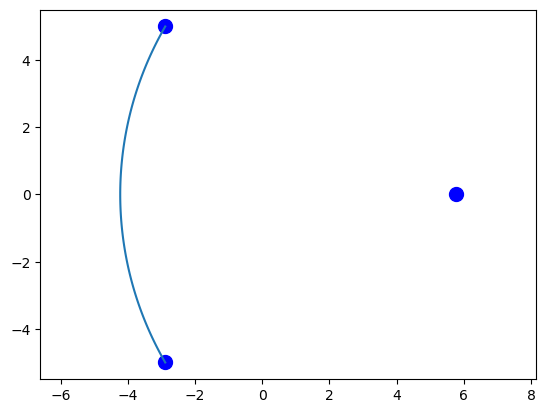

In [30]:
plt.plot(vertices[:, 0], vertices[:, 1], 'b.', markersize=20)
plt.plot(side0[:, 0], side0[:, 1], markersize=20)
plt.axis('equal')

Вычислим матрицу $side1$ с координатами точек, описывающих сторону
треугольника Рело относительно второй вершины $vertices[1]$ . Сторона
представляет собой дугу окружности радиуса $r$ с центром в точке $vertices[1]$ и
значением угла $[π-\beta/2+\alpha, π+\beta/2+\alpha]$

In [31]:
side1=vertices[1]+r*np.transpose([np.cos(np.pi+angle+alpha),
                                 np.sin(np.pi+angle+alpha)])

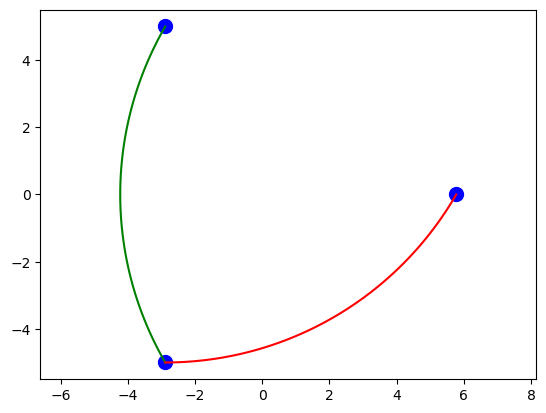

In [32]:
plt.plot(vertices[:, 0], vertices[:, 1], 'b.', markersize=20)
plt.plot(side0[:, 0], side0[:, 1], 'g-', markersize=20)
plt.plot(side1[:, 0], side1[:, 1], 'r-', markersize=20)
plt.axis('equal');

**Этап 3. Моделирование границы треугольника Рело**

Создадим СПИСОК из матриц, каждая их которых содержит координаты точек
одной из сторон треугольника Рело

In [33]:
list_sides=[vertices[i]+r*np.transpose([np.cos(angle+ np.pi+i*alpha), np.sin(angle+ np.pi+i*alpha)])
           for i in range(n)]

С помощью фунции $concatenate$ из расширения $numpy$ объединим массивы,
созданные для каждой из сторон треугольника Рело, в единый массив $sides$

In [34]:
sides=np.concatenate(list_sides)

Построим изображение вершин и всех сторон треугольника Рело

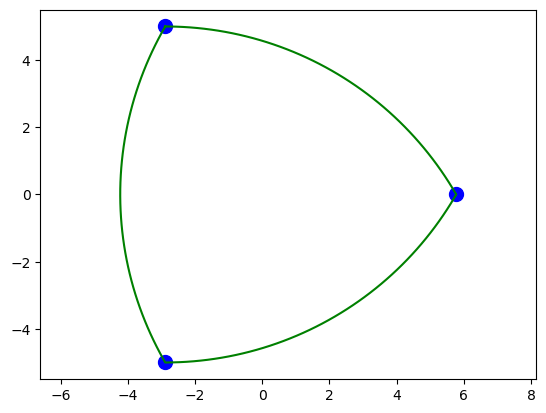

In [35]:
plt.plot(vertices[:, 0], vertices[:, 1], 'b.', markersize=20)
plt.plot(sides[:, 0], sides[:, 1], 'g-', markersize=20)
plt.axis('equal');

## Задание 4.2. Построение правильного многоугольника Рело


In [36]:
import matplotlib.pyplot as plt
import numpy as np
import math

In [37]:
t=np.arange(0, 2*np.pi, 2*np.pi/n)
vertices=center+R*np.transpose([np.cos(t), np.sin(t)])
print(vertices)

[[ 5.77350269  0.        ]
 [-2.88675135  5.        ]
 [-2.88675135 -5.        ]]


In [38]:
alpha=2*np.pi/n
beta=alpha/2

In [39]:
angle=np.linspace(-beta/2, beta/2, N)

In [40]:
side0=vertices[0]+r*np.transpose([np.cos(np.pi+angle),
                                 np.sin(np.pi+angle)])

In [41]:
sides=np.concatenate([vertices[i]+r*np.transpose([np.cos(angle+ np.pi+i*alpha), np.sin(angle+ np.pi+i*alpha)])
           for i in range(n)])

Радиус описаной окружности
$$
R=l/2sinπ/n
$$
Теорема косинусов
$$
l^2=r^2+r^2-2*r*r*cos(\beta)
$$

$$
l=\sqrt{2*r^2(1-cos(\beta))}
$$

In [42]:
l=math.sqrt(2*r**2*(1-math.cos(beta)))

In [43]:
R=l/(2*np.sin(np.pi/n))

## Задание 4.3. Результирующая пользовательская функция


In [44]:
def regular_polygon_Relo(n=3, center=np.array([0, 0]), r=1, N=100):
    assert isinstance(n, int) and n>2 and n%2==1
    assert isinstance(center, nd.ndarray) and center.shape==(2,)
    assert isinstance(r, (int, float)) and r>0
    assert isinstance(N, int) and N>0
    alpha=2*np.pi/n
    beta=alpha/2
    angle=np.linspace(-beta/2, beta/2, N)
    l=math.sqrt(2*r**2*(1-math.cos(beta)))
    R=l/(2*np.sin(np.pi/n))
    t=np.arange(0, 2*np.pi, 2*np.pi/n)
    vertices=center+R*np.transpose([np.cos(t), np.sin(t)])
    sides=np.concatenate([r*np.transpose([np.cos(np.pi+angle),
                                 np.sin(np.pi+angle)])
    for i in range(n)])
    return sides

## Задание 4.4. Тестирование функции

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import relo

In [52]:
relo.regular_polygon_Relo(n=2)

AssertionError: n должно быть нечётным целым числом > 2

In [53]:
relo.regular_polygon_Relo(center=[0, 0])

AssertionError: center должен быть массивом NumPy формы (2,)

In [55]:
relo.regular_polygon_Relo(n=6)

AssertionError: n должно быть нечётным целым числом > 2

In [56]:
relo.regular_polygon_Relo(r=-1)

AssertionError: r должно быть положительным числом

In [57]:
relo.regular_polygon_Relo(N=3.5)

AssertionError: N должно быть положительным целым числом

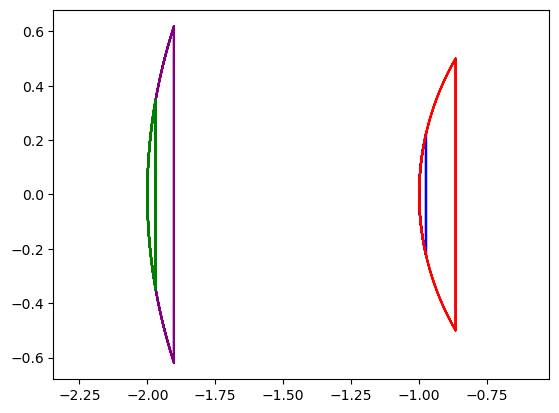

In [59]:
plt.figure()
ax=plt.axes()
sides1 = relo.regular_polygon_Relo(7, np.array([0, 0]), 1, 100)
ax.plot(sides1[:, 0], sides1[:, 1],'b-',markersize=20)
sides2 = relo.regular_polygon_Relo()
ax.plot(sides2[:, 0], sides2[:, 1],'r-',markersize=20)
sides3 = relo.regular_polygon_Relo(n=5, center=np.array([0, 1]), r=2, N=70)
ax.plot(sides3[:, 0], sides3[:, 1],'purple',markersize=20)
sides4 = relo.regular_polygon_Relo(9, np.array([1, 0]), N=150, r=2)
ax.plot(sides4[:, 0], sides4[:, 1],'green',markersize=20)
plt.axis('equal');